# **Tercera práctica - Aerolíneas y satisfacción**
#### **Pedro Félix Jaume y Justin Isaac Muñoz Ordoñez**

En esta práctica se aplican los conceptos y técnicas de aprendizaje automático estudiados en la asignatura al análisis del dataset de satisfacción de pasajeros de una aerolínea, cuyo objetivo final es poder predecir si un pasajero se encuentra satisfecho o no a partir de información demográfica, características del vuelo y valoraciones de distintos servicios. 
Se realiza un proceso completo que incluye el preprocesamiento de los datos, un análisis exploratorio inicial y la comparación del rendimiento de distintos modelos de clasificación. Para cada modelo se lleva a cabo una selección justificada de hiperparámetros y se emplean métricas adecuadas para evaluar su rendimiento, poniendo especial énfasis no solo en los resultados obtenidos, sino en la interpretación de los errores, las fuentes de sesgo y la capacidad de generalización de cada enfoque.

# **1. Preprocesamiento**

### 1.1. Carga y exploración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Configuración para ver todas las columnas
pd.set_option('display.max_columns', None)

# Leemos los datos
df = pd.read_csv("train.csv")

print(f"Dimensiones del dataset: {df.shape}")
df.head() # un vistazo a las primeras filas

Dimensiones del dataset: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


#### Selección de características
Se observa que las variables id y Unnamed: 0 actúan únicamente como identificadores de las instancias. Estas columnas no contienen información relacionada con el comportamiento del pasajero ni con su nivel de satisfacción, y su inclusión en el modelo no aportaría capacidad predictiva adicional.

Por este motivo, ambas columnas se eliminan del conjunto de datos antes de proceder con el preprocesamiento y el entrenamiento de los modelos.

In [2]:
# Ni la columna "id" ni "Unnamed: 0" aportan nada al análisis, las eliminamos y vemos las restantes
columnas_to_drop = ["id", "Unnamed: 0"]
df.drop(columns=columnas_to_drop, inplace=True, errors='ignore')

print(df.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


### 1.2. Limpieza y transformación de datos

#### Gestión de valores nulos (NaNs)

In [3]:
# Un primer vistazo a las columnas:
# vemos qué columnas tienen valores vacíos NaN y qué tipo de datos son cada una
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    1039

Se observa que prácticamente todas las variables presentan valores completos para las 103.904 instancias disponibles. La única excepción es la variable Arrival Delay in Minutes, que contiene 310 valores nulos.

Dado que esta variable representa una magnitud continua y que su distribución puede verse afectada por valores extremos (vuelos con grandes retrasos), se opta por imputar los valores faltantes utilizando la mediana en lugar de eliminar las filas afectadas.

In [4]:
# A raíz de ver que la columna "Arrival Delay in Minutes" tiene 310 valores nulos, investigamos esas filas
vuelos_con_nulos = df[df['Arrival Delay in Minutes'].isnull()]
# Mostramos unos cuantos ejemplos de esta búsqueda
vuelos_con_nulos.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
213,Female,Loyal Customer,38,Business travel,Eco,109,5,3,3,3,5,5,5,5,5,2,4,1,1,5,31,NaN,satisfied
1124,Male,Loyal Customer,53,Personal Travel,Eco,1012,3,2,3,4,4,3,4,4,4,4,4,3,3,4,38,NaN,neutral or dissatisfied
1529,Male,Loyal Customer,39,Business travel,Business,733,2,5,5,5,2,4,3,2,2,2,2,2,2,3,11,NaN,neutral or dissatisfied
2004,Female,disloyal Customer,26,Business travel,Business,1035,3,3,3,1,2,3,2,2,3,3,4,5,5,2,41,NaN,neutral or dissatisfied
2108,Female,Loyal Customer,24,Personal Travel,Eco,417,2,1,2,2,5,2,5,5,1,4,2,1,2,5,1,NaN,neutral or dissatisfied


In [5]:
# Subtituye las filas con valores NaN por la mediana (sabiendo que "Arrival Delay in Minutes" es la única con NaN)
median_arrival_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_arrival_delay)

# Imprimir valores nulos restantes
remainingNulls = df.isnull().sum().sum()
print(f"Valores nulos restantes: {remainingNulls}")

Valores nulos restantes: 0


### 1.3. Etiquetado de características
Hemos observado anteriormente que hay 4 características y 1 target que debemos etiquetar si queremos aplicar modelos de Aprendizaje Automático, pues sus valores no son ni un integer ni float, actualmente son tipo object.

Estas características son Gender, Customer Type, Type of Travel y Class. Además, se debe etiquetar el target Satisfaction.

**Antes de etiquetar Gender, ¿qué valores posibles tiene en el dataset?**

In [6]:
# Comprobamos los posibles valores de Gender
print(df['Gender'].value_counts())

Gender
Female    52727
Male      51177
Name: count, dtype: int64


Sólo hay dos valores posibles (Male/Female), así que es una variable binaria.
Etiquetaremos Male como '0' y Female como '1'.

**Antes de etiquetar Customer Type, ¿qué valores posibles tiene en el dataset?**

In [7]:
# Comprobamos los posibles valores de Customer Type
print(df['Customer Type'].value_counts())

Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64


Sólo hay dos valores posibles (Loyal Customer/disloyal Customer), así que es una variable binaria.
Etiquetaremos Loyal Customer como '0' y disloyal Customer como '1'.

**Antes de etiquetar Type of travel, ¿qué valores posibles tiene en el dataset?**

In [8]:
# Comprobamos los posibles valores de Type of Travel
print(df['Type of Travel'].value_counts())

Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64


Sólo hay dos valores posibles (Business travel/Personal Travel), así que es una variable binaria.
Etiquetaremos Business travel como '0' y Personal Travel como '1'.

**Antes de etiquetar Class, ¿qué valores posibles tiene en el dataset?**

In [9]:
# Comprobamos los posibles valores de Class
print(df['Class'].value_counts())

Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64


Hay tres valores posibles (Business/Eco/Eco Plus).
Etiquetaremos Business '0', Eco '1' y Eco Plus '2'.

**Antes de etiquetar el target Satisfaction, ¿qué valores posibles tiene en el dataset?**

In [10]:
# Comprobamos los posibles valores de Satisfaction
print(df['satisfaction'].value_counts())

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


Hay dos salidas posibles (neutral or dissatisfied/satisfied), así que es una variable binaria.
Etiquetaremos '0' a neutral or dissatisfied y '1' a satisfied.

Ahora creamos un diccionario con las reglas de etiquetado y las aplicamos al dataset

In [11]:
# Definimos el mapeo según los valores que hemos visto con value_counts
mapeo = {
    'Gender': {'Male': 0, 'Female': 1},
    'Customer Type': {'Loyal Customer': 0, 'disloyal Customer': 1},
    'Type of Travel': {'Business travel': 0, 'Personal Travel': 1},
    'Class': {'Business': 0, 'Eco': 1, 'Eco Plus': 2},
    'satisfaction': {'neutral or dissatisfied': 0, 'satisfied': 1}
}

# Aplicamos la transformación
df.replace(mapeo, inplace=True)

# Comprobamos que no haya valores nulos luego del mapeo
print(f"Valores nulos totales: \n{df.isnull().sum()}")

Valores nulos totales: 
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64


C:\Users\Pedriito\AppData\Local\Temp\ipykernel_21244\1028163163.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(mapeo, inplace=True)


Las clases están balanceadas. Los futuros modelos no deberían tener problema en identificar las 2 posibles clases.

### 1.5 Preprocesamiento para el modelo

Modelos como Regresión Logística o SVM son sensibles a la escala. Por ello, el siguiente objetivo es transformar el dataset para que sea apto para los modelos. Aplicamos StandardScaler para estandarizar los datos (media: 0, desviación típica: 1), evitando que variables con rangos grandes (p.e. Flight Distance, Age) tengan más peso que otros. 

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separamos el target (y) del resto de características (X)
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

# 2. Dividimos en Train y Test (por ejemplo, 80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Normalización (StandardScaler)
scaler = StandardScaler()

# Ajustamos el escalador solo con los datos de TRAIN y transformamos ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocesamiento finalizado. Datos normalizados y listos.")

Preprocesamiento finalizado. Datos normalizados y listos.


# **2. Análisis Exploratorio de Datos (EDA)**

### 2.1. Diagnóstico del balanceo de clases
El primer paso esencial en cualquier problema de clasificación es analizar la distribución de la variable que queremos predecir (satisfaction). El objetivo es determinar si existe un desequilibrio de clases.

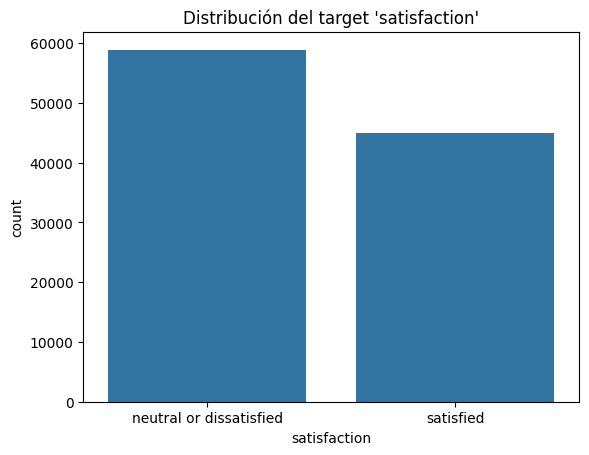

In [13]:
# Visualizamos el balanceo del Target
sns.countplot(x='satisfaction', data=df)
plt.title("Distribución del target 'satisfaction'")
plt.xticks([0, 1], ['neutral or dissatisfied', 'satisfied'])
plt.show()

Los resultados muestran una distribución aproximada del 56% para pasajeros insatisfechos y 44% para satisfechos. Al no haber una clase que represente, por ejemplo, el 90% de los datos, descartamos problemas de "clasificación trivial" (donde el modelo aprende a predecir siempre la mayoría para obtener un buen resultado aparente). Esta distribución equilibrada justifica técnicamente el uso del Accuracy (exactitud) como métrica de comparación principal.

### 2.2. Análisis de Relaciones Lineales (Matriz de Correlación)

Una vez comprendido el target, procedemos a estudiar cómo se relacionan todas las variables entre sí. Utilizamos el coeficiente de correlación de Pearson para identificar asociaciones lineales. Este análisis es fundamental para detectar la multicolinealidad (variables independientes muy relacionadas entre sí) y para identificar qué factores del servicio tienen una relación más directa con la satisfacción final.

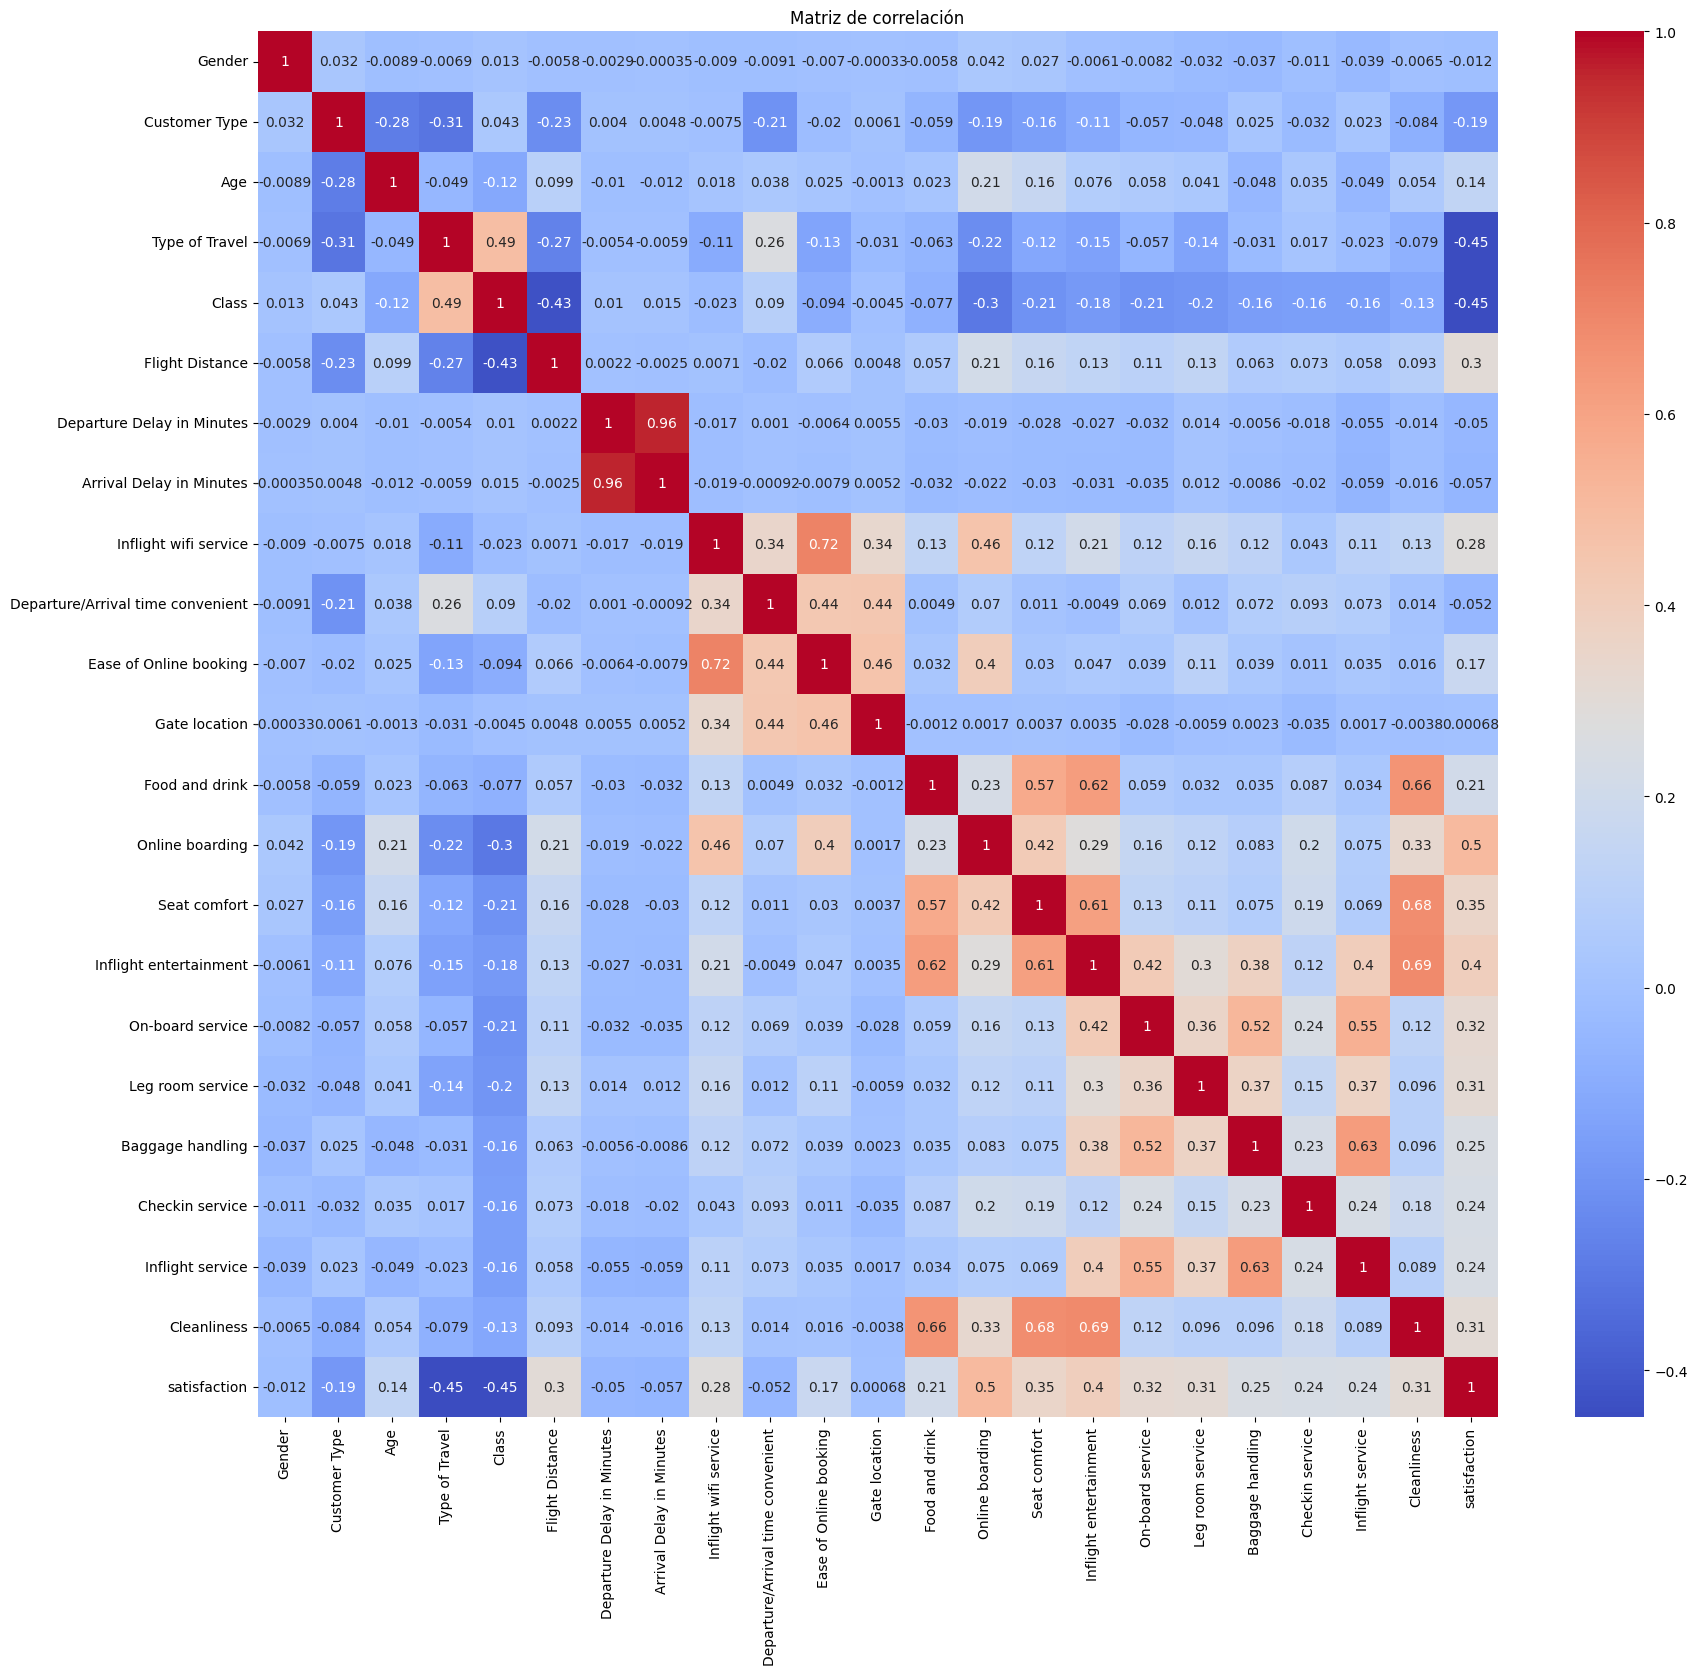

In [14]:
# Seleccionamos las características más importantes para visualizar
# Esto ayudará a diferenciar mejor entre las clases
caracteristicas_de_interes = ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
                              'Inflight wifi service', 'Departure/Arrival time convenient',
                              'Ease of Online booking', 'Gate location', 'Food and drink',
                             'Online boarding', 'Seat comfort', 'Inflight entertainment',
                             'On-board service', 'Leg room service', 'Baggage handling',
                             'Checkin service','Inflight service' , 'Cleanliness', 'satisfaction']

plt.figure(figsize=(20, 18))
sns.heatmap(df[caracteristicas_de_interes].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

El análisis de los resultados nos presenta la siguiente información:

- **Pilares de la satisfacción**

Se revela que variables de servicio como Online boarding, Inflight entertainment y Seat comfort presentan los coeficientes de correlación positiva más altos respecto al target. Esto sugiere que la digitalización del embarque y el confort físico son los pilares principales de la experiencia del cliente.

- **Correlaciones negativas**

Se observa que Type of Travel y Class tienen una alta relación con la satisfacción, pero de signo negativo (dependiendo del mapeo puede cambiar el signo). Esto es altamente relevante, ya que indica que los viajes personales (mapeados como 1 para el tipo de vuelo) y las clases más económicas (mapeadas como 1 y 2 para la clase del pasajero) reducen drásticamente la probabilidad de satisfacción. La experiencia del cliente está, por tanto, fuertemente condicionada por el segmento económico al que pertenece y el nivel de confort contratado.

- **Variables de bajo impacto**

Variables como Gate location y Gender muestran una correlación cercana a cero, lo que nos indica de antemano que el sexo del pasajero y la localización de la puerta no son factores determinantes por sí solos para predecir si estará satisfecho el pasajero.

- **Redundancia por multicolinealidad**

Se observa una correlación cercana a 1.00 entre Departure Delay in Minutes y Arrival Delay in Minutes. Esto indica que ambas variables aportan prácticamente la misma información. Desde un punto de vista de optimización de modelos (especialmente para Regresión Logística y Perceptrón), esto sugiere que podríamos descartar una de las dos características para reducir la complejidad del modelo y evitar problemas de varianza inestable en los coeficientes.

- **Triangulación del pasajero**

    - Tipo de Viaje vs. Clase (0.50): Existe una relación moderada-fuerte que confirma una realidad del negocio: los viajes de negocios suelen estar asociados a la clase Business.

    - Clase vs. Distancia (-0.43): Este hallazgo es de especial relevancia. La correlación negativa indica que, en este dataset, los vuelos de mayor distancia tienden a estar asociados con valores numéricos de clase más bajos (Clase 0: Business). Es decir, que los viajes en clase Business tienden a ser más largos.


## 2.3. Segmentación mediante Clustering

Para identificar los distintos perfiles de pasajeros, se aplica el algoritmo de aprendizaje no supervisado K-Means. Como paso previo, se normalizaron las variables estratégicas (Age, Flight Distance, Inflight wifi service, Class y Type of Travel) para asegurar que las diferentes escalas no sesgaran el modelo.

In [15]:
# 1. Selección de variables estratégicas
cluster_cols = ['Age', 'Flight Distance', 'Inflight wifi service', 'Type of Travel']
X_clus = StandardScaler().fit_transform(df[cluster_cols])

### 2.3.1. Selección de características

La elección de las variables Age, Flight Distance, Inflight wifi service y Type of Travel responde a criterios de independencia estadística y representatividad del negocio:

- **Preferencia de Type of Travel sobre Class**: Se ha optado por incluir el tipo de viaje en lugar de la clase del asiento debido a la alta colinealidad detectada entre Class y Flight Distance. Dado que los vuelos de larga distancia suelen estar fuertemente vinculados a clases superiores (Business), incluir ambas variables podría sesgar el algoritmo K-Means, dándoles un peso redundante. Type of Travel aporta una dimensión distinta y fundamental: la motivación del pasajero (negocios vs. personal), que es un motor de satisfacción independiente de la distancia física.

- **Descarte de variables de retraso (Arrival/Departure Delay)**: A pesar de su importancia teórica, los retrasos se han excluido del clustering para evitar el ruido provocado por valores extremos (outliers). Los retrasos no siguen una distribución normal y unos pocos vuelos con demoras excesivas podrían distorsionar los centroides de los clústeres, creando grupos basados en anomalías puntuales en lugar de perfiles de usuario consistentes.

- **Representatividad Multidimensional**:
    - Age: Capta el perfil demográfico y generacional.
    - Flight Distance: Representa la magnitud y el cansancio asociado al trayecto.
    - Inflight wifi service: Actúa como el indicador clave de la experiencia de servicio a bordo.

### 2.3.2. Selección de K

Para determinar el número óptimo de clústeres ($k$), se utiliza el Método del Codo analizando la evolución de la inercia (Suma de los Cuadrados dentro del Clúster).

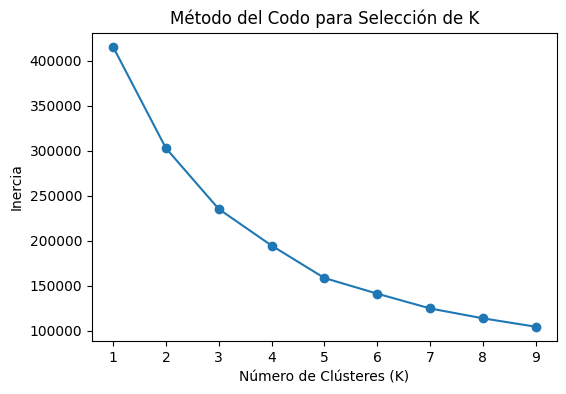


--- Tabla de Métricas para Selección de K ---
 K       Inercia      Ganancia  Salto_Abrupto
 1 415616.000000           NaN            NaN
 2 302892.028586 112723.971414            NaN
 3 235239.227059  67652.801527   45071.169887
 4 194589.470570  40649.756490   27003.045037
 5 158533.090574  36056.379995    4593.376494
 6 141120.284581  17412.805994   18643.574002
 7 124702.038676  16418.245904     994.560089
 8 113707.779525  10994.259152    5423.986752
 9 104373.223541   9334.555984    1659.703168

Nota: El K óptimo suele ser donde el 'Salto_Abrupto' es más alto después de K=2.


In [16]:
from sklearn.cluster import KMeans

# Evaluación del número óptimo de clústeres (Método del Codo)
# Justificación: Evaluamos la inercia para asegurar una elección estadísticamente sólida
inercias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clus)
    inercias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 10), inercias, marker='o')
plt.title("Método del Codo para Selección de K")
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Inercia")
plt.show()

# Análisis Numérico de la Inercia
df_metrica = pd.DataFrame({
    'K': range(1, 10),
    'Inercia': inercias
})
# Diferencia simple (Ganancia de información)
df_metrica['Ganancia'] = df_metrica['Inercia'].diff().abs()
# Diferencia de diferencias (El "frenazo" o codo)
df_metrica['Salto_Abrupto'] = df_metrica['Ganancia'].diff().abs()

print("\n--- Tabla de Métricas para Selección de K ---")
print(df_metrica.to_string(index=False))
print("\nNota: El K óptimo suele ser donde el 'Salto_Abrupto' es más alto después de K=2.")

Se observa que el cambio más abrupto en la inercia ocurre al pasar de 2 a 3 clústeres (con una reducción de la inercia de ~71,600 unidades).

Aunque el "codo" matemático más marcado se sitúa en $k=3$, se ha seleccionado un valor de $k=4$. Esta decisión responde a un criterio de equilibrio entre la eficiencia estadística y la utilidad de negocio, permitiendo una segmentación más granular que captura matices adicionales en el comportamiento de los pasajeros sin llegar a una fragmentación excesiva de los datos.

### 2.3.3. Segmentación y Análisis

Tras elegir el mejor número de clústeres, ejecutamos el algoritmo de aprendizaje no supervisado K-Means para agrupar a los pasajeros por similitud. Dado que trabajamos en un espacio multidimensional, utilizamos PCA (Principal Component Analysis) para proyectar los datos en un plano bidimensional, facilitando la interpretación visual de los clústeres y analizando qué variables originales tienen más peso en la formación de estos grupos.

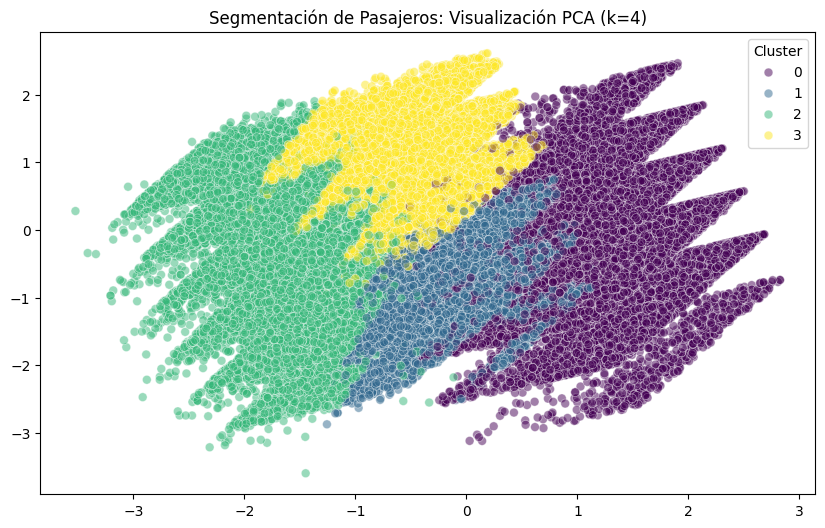

Pesos de las variables en los Componentes Principales:


,PC1 (Eje X),PC2 (Eje Y)
Age,-0.309459,-0.452986
Flight Distance,-0.642847,-0.246876
Inflight wifi service,-0.244429,0.845036
Type of Travel,0.656687,-0.140604


Análisis de perfiles por clúster (medias):


,Age,Flight Distance,Inflight wifi service,Type of Travel,satisfaction
Cluster,,,,,
0,38.251563,784.091039,2.520139,1.000000,0.101397
1,37.948233,833.887785,1.428233,0.000000,0.394631
2,44.240037,2884.756126,2.776948,0.005014,0.738732
3,38.484057,782.201668,3.898647,0.000000,0.619808


In [17]:
from sklearn.decomposition import PCA

# Aplicación de K-Means con K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_clus)
df['Cluster'] = kmeans.labels_

# Visualización mediante PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clus)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='viridis', s=40, alpha=0.5)
plt.title('Segmentación de Pasajeros: Visualización PCA (k=4)')
plt.show()

# Extracción de pesos por cada Componente
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1 (Eje X)', 'PC2 (Eje Y)'], 
    index=cluster_cols
)

print("Pesos de las variables en los Componentes Principales:")
display(loadings)

# Análisis de características por Clúster
print("Análisis de perfiles por clúster (medias):")
display(df.groupby('Cluster')[cluster_cols + ['satisfaction']].mean())

Los pesos de las variables en los Componentes Principales nos indican qué variables originales tienen más peso en la construcción de los ejes X e Y de nuestro gráfico de dispersión. Esto nos permite entender la lógica matemática detrás de la separación de los pasajeros.

- PC1 (Eje X): Este componente está dominado por el **Type of Travel** (0.66) y la **Flight Distance** (-0.64). Dado que el viaje personal se mapeó con el valor 1, un valor alto en el PC1 representa a viajeros personales de corta distancia. Por el contrario, valores negativos en este eje representan a viajeros de negocios de larga distancia.

- PC2 (Eje Y): Este eje está definido casi exclusivamente por el **Inflight wifi service** (0.85). El PC2 separa a los pasajeros según su nivel de satisfacción digital. Hacia arriba en el gráfico (valores positivos) encontraremos a quienes valoran positivamente el Wifi, y hacia abajo a quienes no.

Una vez comprendidos los ejes, analizamos las medias de cada clúster para identificar el perfil real de pasajero que representa cada grupo y cómo esto afecta a la variable satisfaction.

- Clúster 0: Representa al 100% de **viajeros personales de corta distancia** con una **valoración de Wifi intermedia**. Su satisfacción es ínfima (10%). Este resultado valida la correlación negativa que encontramos en el EDA: el viaje personal es el mayor predictor de insatisfacción.

- Clúster 1: Son **viajeros de negocios** pero con la **valoración de Wifi más baja** de todo el dataset (1.43). Esto castiga su satisfacción bajándola al 39%, a pesar de ser un segmento que suele ser más fiel.

- Clúster 2: Es el grupo de mayor edad media (44 años) y el único especializado en **larga distancia** (2884 km). Son casi exclusivamente **viajeros de negocios**. Este clúster tiene la satisfacción más alta (74%), lo que sugiere que la aerolínea cuida mejor al pasajero de largo radio.

- Clúster 3: **Viajeros de negocios en trayectos cortos** que **puntúan muy alto el Wifi** (3.90). Su satisfacción es alta (62%), demostrando que en vuelos cortos de negocios, la conectividad es el factor diferencial.

### 2.3.4. Conclusión

El análisis de segmentación mediante K-Means y PCA se identifican cuatro perfiles clave: 
- El Clúster 0 (Viajero Personal/Corta Distancia) presenta un "Abismo" de satisfacción de solo el 10%, sugiriendo un **descuido frente al sector corporativo**
- El Clúster 1 (Negocios/Bajo Wifi) muestra una **oportunidad de mejora**, ya que su satisfacción cae al 39% por deficiencias digitales
- El Clúster 2 (Premium/Larga Distancia) representa al **cliente ideal** con un 74% de satisfacción
- El Clúster 3 demuestra que **la tecnología es un "Salvavidas"**, pues un buen Wifi eleva la satisfacción al 62% incluso en vuelos cortos. 

En conjunto, estos hallazgos validan que la satisfacción depende de la interacción entre el **motivo del viaje** y la **calidad de la conectividad**, por lo que son los puntos que se requieren mejorar para obtener mayor satisfacción por parte de los pasajeros.

# **3. Selección de hiperparámetros**

La elección de hiperparámetros es crucial para optimizar el rendimiento de cada uno de los modelos que se van a entrenar. Según
los hiperparámetros seleccionados y los valores probados para cada unos de ellos, la capacidad de generalizarización, la complejidad o
la regularización del modelo pueden cambiar significativamente.

#### **Perceptrón**

Este modelo de clasificación lineal realiza la predicción a partir de una combinación lineal de las variables de entrada. En este problema, sirve como un modelo sencillo que permite evaluar hasta qué punto la separación lineal es suficiente para poder clasificar la satisfacción del pasajero a partir de las características disponibles. Aunque, al tratarse de un modelo simple, su rendimiento depende mucho de la selección de hiperparámetros. Por ese motivo, resulta necesario ajustar los hiperparámetros para controlar la complejidad del modelo y mejorar su capacidad de generalizar (actuar frente a datos nuevos).

In [18]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Definimos el modelo
perceptron = Perceptron(
    random_state=42, 
    penalty='l2' # Se usa regularización L2 para que el hiperparámetro alpha tenga efecto
    )

# Definimos los hiperparámetros a explorar
param_grid_perceptron = {
    # alpha: regula los pesos que aprende el modelo a lo largo de los ciclos de aprendizaje.
    # Su principal función es penalizar pesos grandes para evitar el sobreajuste.
    # valores inferiores de alpha implican una regularización más débil, que peligra de 
    # asignar pesos grandes a algunas variables y sobreajustar el modelo
    'alpha': [0.0001, 0.001, 0.01],

    # max_iter: número máximo de iteraciones para el entrenamiento
    # valores bajos pueden llevar a un entrenamiento incompleto o que no converge
    'max_iter': [500, 1000, 2000]
}

# Otros hiperparámetros del Perceptron como eta0, learning_rate, early_stopping, etc.
# no se han contemplado por buscar la optimización del entrenamiento del modelo en cuanto coste computacional y de tiempo.
# Nosotros, priorizamos aquellos hiperparámetros que impactan en la complejidad, generalización y regularización del modelo.

# Configuramos GridSearchCV
grid_perceptron = GridSearchCV(
    estimator=perceptron,
    param_grid=param_grid_perceptron,
    cv=5,
    scoring='accuracy',
    return_train_score=True  # opcional: para ver también el rendimiento en entrenamiento
)

# Ejecutamos la búsqueda
grid_perceptron.fit(X_train_scaled, y_train)

# Mostramos los mejores hiperparámetros y los guardamos
print("Los mejores hiperparámetros encontrados:", grid_perceptron.best_params_)
best_params_perceptron = grid_perceptron.best_params_
print("Accuracy media (CV):", grid_perceptron.best_score_)

# Crear un DataFrame con todos los resultados
results_df = pd.DataFrame(grid_perceptron.cv_results_)[
    ['param_alpha', 'param_max_iter', 'mean_test_score']
]

# Renombramos columnas para que se vea más claro
results_df = results_df.rename(columns={
    'param_alpha': 'alpha',
    'param_max_iter': 'max_iter',
    'mean_test_score': 'accuracy_mean'
})

print("\nTodos los resultados de combinar hiperparámetros:")
print(results_df.sort_values(by='accuracy_mean', ascending=False))

Los mejores hiperparámetros encontrados: {'alpha': 0.0001, 'max_iter': 500}
Accuracy media (CV): 0.820133832415495

Todos los resultados de combinar hiperparámetros:
    alpha  max_iter  accuracy_mean
0  0.0001       500       0.820134
1  0.0001      1000       0.820134
2  0.0001      2000       0.820134
3  0.0010       500       0.802967
4  0.0010      1000       0.802967
5  0.0010      2000       0.802967
6  0.0100       500       0.793475
7  0.0100      1000       0.793475
8  0.0100      2000       0.793475


**Regresión logística**

La regresión logística es un modelo de clasificación lineal que estima la probabilidad de pertenecer a una clase a partir de una combinación lineal de las variables de entrada. En nuestro caso, permite evaluar hasta qué punto una separación lineal, en términos probabilísticos, es suficiente para modelar la satisfacción del pasajero. Dado que el dataset es grande y contiene variables de distintas naturalezas (heterogéneas), resulta importante controlar la complejidad del modelo mediante la regularización. Por ese motivo, la selección de hiperparámetros para este modelo está orientada a ajustar el nivel de regularización y el tipo, con el objetivo de mejorar la capacidad de generalizar del modelo.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

# Modelo
logreg = LogisticRegression(
    solver='saga', # es un algoritmo numérico que usa la regresión logística diseñado para datasets grandes
    max_iter=2000,
    random_state=42,
)

# Hiperparámetros
param_grid_logreg = {
    # C: controla el nivel de regularización (en Reg. Log. funciona de forma inversa que perceptron),
    # valores inferiores implican una regularización más fuerte, mientras que
    # valores mayores dan un modelo más flexible, que puede sobreajustar
    'C': [0.01, 0.1, 1],

    # balance entre dos tipos de regularización: L1 (Lasso) y L2 (Ridge)
    # ambos controlan cómo se actua frente a pesos del modelo, regularizando pesos grandes (modelo complejo) y pequeños (modelo simple)
    # L1 puede eliminar variables al asignarles peso cero cuando aporta poca información al modelo frente al coste que tiene mantenerlas, 
    # mientras que L2 tiende a distribuir el peso entre todas las variables
    'l1_ratio': [0, 0.5, 1]  # 0 = L2, 1 = L1, 0.5 = mezcla de ambos tipos
}

# Otros hiperparámetros disponibles en la regresión logística como solver, max_iter,
# class_weight o tol no se han incluido, ya que afectan principalmente a la eficiencia u optimización del entrenamiento. 
# Como en el caso del Perceptrón, la prioridad es probar hiperparámetros que impactan en la complejidad y regularización del modelo.

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_logreg,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

grid_logreg.fit(X_train_scaled, y_train)

print("Los mejores hiperparámetros encontrados:", grid_logreg.best_params_)
best_params_logreg = grid_logreg.best_params_
print("Accuracy media (CV):", grid_logreg.best_score_)

# Resultados completos
results_df = pd.DataFrame(grid_logreg.cv_results_)[
    ['param_C', 'param_l1_ratio', 'mean_test_score']
].rename(columns={
    'param_C': 'C',
    'param_l1_ratio': 'l1_ratio',
    'mean_test_score': 'accuracy_mean'
})

print("\nTodos los resultados de combinar hiperparámetros:")
print(results_df.sort_values(by='accuracy_mean', ascending=False))

Los mejores hiperparámetros encontrados: {'C': 0.01, 'l1_ratio': 1}
Accuracy media (CV): 0.8752571790399966

Todos los resultados de combinar hiperparámetros:
      C  l1_ratio  accuracy_mean
2  0.01       1.0       0.875257
1  0.01       0.5       0.875245
0  0.01       0.0       0.875137
5  0.10       1.0       0.875125
4  0.10       0.5       0.875065
7  1.00       0.5       0.875041
3  0.10       0.0       0.875029
6  1.00       0.0       0.875029
8  1.00       1.0       0.875029


#### **SVM** 
Este modelo necesita una correcta selección de hiperparámetros porque: 
- Puede tener muchos grados de libertad. Según el kernel elegido y los hiperparámetros, las forma de las fronteras de decisión pueden ser muy diferentes: líneas planas, curvas suaves o retorcidas, incluso "islas". 
- Es muy sensible a la escala de los datos (gestionado anteriormente cuando se empleó normalización) 

En este caso, los datos no son linealmente separables, ya que la satisfacción del pasajero depende de múltiples variables heterogéneas, cuya relación con el target no sigue una frontera lineal simple. Por este motivo, usaremos un kernel tipo RBF (Radial Basis Function), una técnica matemática usada por el SVM para modelar relaciones no lineales entre los features y el target. Este kernel proyecta los datos en un espacio de mayor dimensión donde es posible encontrar de forma más clara la separación entre clases.

In [20]:
from sklearn.svm import SVC 
from sklearn.model_selection import GridSearchCV 
import pandas as pd 

# Definimos el modelo SVM 
svm = SVC( 
    kernel='rbf', 
    random_state=42 
) 

# Definimos los hiperparámetros a explorar 
param_grid_svm = { 
    # C: controla la penalización por errores de clasificación en el entrenamiento 
    # Cuanto más grande sea C, menor es la regularización, el modelo es fuertemente penalizado por cometer errores,
    # lo que lleva a aumentar la complejidad del modelo por querer clasificar todo correctamente, peligrando de sobreajustar. 
    'C': [0.1, 1, 10], # regularización fuerte, media y débil 
    
    # gamma: controla la influencia de un ejemplo individual de entrenamiento. 
    # la influencia se puede definir como "cuánto afecta un punto a la forma de la frontera de decisión según si está lejos o cerca" 
    # Una influencia baja que puntos lejanos pueden afectar en una región grande de forma suave, 
    # mientras que una influencia alta hace que los puntos afecten sólo de cerca, poniendo en riesgo el modelo por poder aprender ruido. 
    'gamma': [0.01, 0.1, 1] 
} 

# Otros hiperparámetros disponibles en SVM como kernel, degree, coef0, shrinking o tol
# no se han considerado, ya que la elección del kernel se ha realizado previamente y el resto afectan principalmente a detalles
# de la optimización o eficiencia del entrenamiento. 
# Al igual que en los modelos anteriores, se prioriza el ajuste de los hiperparámetros que influyen directamente en la complejidad
# del modelo y en su capacidad de generalización.

# Configuramos GridSearchCV 
grid_svm = GridSearchCV( 
    estimator=svm, 
    param_grid=param_grid_svm, 
    cv=3, 
    scoring='accuracy', 
    return_train_score=True,
    n_jobs=-1 # acelera el proceso porque el coste computacional es alto
)
 
# Ejecutamos la búsqueda 
grid_svm.fit(X_train_scaled, y_train) 
# Mejores hiperparámetros 
print("Los mejores hiperparámetros encontrados:", grid_svm.best_params_) 
best_params_svm = grid_svm.best_params_
print("Accuracy media (CV):", grid_svm.best_score_) 

# Resultados completos 
results_df = pd.DataFrame(grid_svm.cv_results_)[ 
    ['param_C', 'param_gamma', 'mean_test_score'] 
    ].rename(columns={ 
        'param_C': 'C', 
        'param_gamma': 'gamma', 
        'mean_test_score': 'accuracy_mean' 
    }) 

print("\nTodos los resultados de combinar hiperparámetros:")
print(results_df.sort_values(by='accuracy_mean', ascending=False))

Los mejores hiperparámetros encontrados: {'C': 1, 'gamma': 0.1}
Accuracy media (CV): 0.9554876487915722

Todos los resultados de combinar hiperparámetros:
      C  gamma  accuracy_mean
4   1.0   0.10       0.955488
7  10.0   0.10       0.951818
6  10.0   0.01       0.947499
1   0.1   0.10       0.937033
3   1.0   0.01       0.936961
0   0.1   0.01       0.916533
8  10.0   1.00       0.801463
5   1.0   1.00       0.784801
2   0.1   1.00       0.638548


**Árboles de decisión**

Los árboles de decisión son modelos no lineales que construyen la clasificación a partir de una serie de reglas basadas en las características de entrada. Así, de forma natural, se capturan relaciones complejas entre características, lo cuál es especialmente relevante en este problema, donde la satisfacción del pasajero depende de una combinación de distintos factores relacionados con el vuelo y sus servicios.

Los árboles pueden volverse excesivamente complejos, llegando a sobreajustar el modelo al dataset. Por este motivo, resulta funamental controlar el tamaño de los árboles mediante hiperparámetros que controlen su profundidad y condiciones de división.

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Definimos el modelo Árbol de Decisión
dt = DecisionTreeClassifier(
    random_state=42
)

# Definimos los hiperparámetros a explorar
param_grid_dt = {
    # max_depth: profundidad máxima del árbol
    # Limita el número de decisiones encadenadas
    # None permite que el árbol crezca sin límite (riesgo de sobreajuste)
    'max_depth': [5, 10, 20, None],

    # min_samples_split: número mínimo de muestras que necesita un nodo como para dividirse según otra decisión
    # Valores mayores fuerzan divisiones más generales
    'min_samples_split': [2, 10, 20]
}

# Otros hiperparámetros disponibles en los Árboles de Decisión como criterion,
# min_samples_leaf, max_features o splitter no se han incluido, ya que afectan a aspectos 
# más específicos del proceso de partición o introducen un nivel adicional de complejidad en el análisis. 
# Como ya se ha hecho mención, la prioridad es ajustar hiperparámetros que controlan directamente el 
# crecimiento del árbol y su tendencia al sobreajuste, con el objetivo de mejorar la generalización del modelo.


# Configuramos GridSearchCV
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

# Entrenamos el modelo
grid_dt.fit(X_train_scaled, y_train)

# Mejores hiperparámetros
print("Los mejores hiperparámetros encontrados:", grid_dt.best_params_)
best_params_dt = grid_dt.best_params_
print("Accuracy media (CV):", grid_dt.best_score_)

# Resultados completos
results_df = pd.DataFrame(grid_dt.cv_results_)[
    ['param_max_depth', 'param_min_samples_split', 'mean_test_score']
].rename(columns={
    'param_max_depth': 'max_depth',
    'param_min_samples_split': 'min_samples_split',
    'mean_test_score': 'accuracy_mean'
})

print("\nTodos los resultados de combinar hiperparámetros:")
print(results_df.sort_values(by='accuracy_mean', ascending=False))

Los mejores hiperparámetros encontrados: {'max_depth': 20, 'min_samples_split': 20}
Accuracy media (CV): 0.9499055779487217

Todos los resultados de combinar hiperparámetros:
   max_depth  min_samples_split  accuracy_mean
8         20                 20       0.949906
11      None                 20       0.948895
7         20                 10       0.948787
6         20                  2       0.947307
10      None                 10       0.946970
5         10                 20       0.943686
4         10                 10       0.943602
9       None                  2       0.943277
3         10                  2       0.943265
2          5                 20       0.905080
0          5                  2       0.905080
1          5                 10       0.905080


**Random Forest**

Este es un modelo basado en un conjunto de árboles de decisión entrenados de forma independiente sobre distintas particiones aleatorias del dataset. A diferencia de un árbol individual, que puede sobreajustarse, Random Forest combina múltiples árboles para reducir la varianza del modelo y mejorar su capacidad de generalizar (predecir correctamente ante datos nuevos).

En este problema, donde la satisfacción del pasajero depende de múltiples variables heterogéneas, Random Forest resulta muy adecuado, pues tiene la capacidad de capturar relaciones no lineales complejas mientras mantiene un equilibrio entre rendimiento y robustez. Además, es un tipo de modelo que puede escalar fácilmente ante datasets grandes (como es nuestro caso), lo que lo combierte en una opción práctica y eficiente.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Definimos el modelo Random Forest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1  # paralelizamos el entrenamiento de los árboles
)

# Definimos los hiperparámetros a explorar
param_grid_rf = {
    # n_estimators: número de árboles del bosque
    # Más árboles suelen mejorar el rendimiento, pero aumentan el coste computacional
    'n_estimators': [100, 200, 300],

    # max_depth: profundidad máxima de cada árbol
    # None permite árboles profundos; valores menores limitan la complejidad
    'max_depth': [None, 10, 20]
}

# Otros hiperparámetros disponibles en Random Forest como max_features,
# min_samples_split, min_samples_leaf o bootstrap no se han incluido en la búsqueda,
# ya que el propio enfoque de Random Forest ya introduce aleatoriedad y reduce el
# sobreajuste de forma natural. 
# Ya se ha mencionado que el objetivo es ajustar hiperparámetros que controlan el número de 
# modelos del conjunto y la complejidad de cada árbol individual, por su impacto directo en el rendimiento y la generalización.


# Configuramos GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

# Entrenamos el modelo
grid_rf.fit(X_train_scaled, y_train)

# Mejores hiperparámetros
print("Los mejores hiperparámetros encontrados:", grid_rf.best_params_)
best_params_rf = grid_rf.best_params_
print("Accuracy media (CV):", grid_rf.best_score_)

# Resultados completos
results_df = pd.DataFrame(grid_rf.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'mean_test_score']
].rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'mean_test_score': 'accuracy_mean'
})

print("\nTodos los resultados de combinar hiperparámetros:")
print(results_df.sort_values(by='accuracy_mean', ascending=False))


Los mejores hiperparámetros encontrados: {'max_depth': None, 'n_estimators': 300}
Accuracy media (CV): 0.9614787765853517

Todos los resultados de combinar hiperparámetros:
   n_estimators max_depth  accuracy_mean
2           300      None       0.961479
7           200        20       0.961262
8           300        20       0.961214
1           200      None       0.961214
0           100      None       0.961010
6           100        20       0.960925
5           300        10       0.945057
4           200        10       0.944925
3           100        10       0.944564


# **4. Evaluación de los modelos**

En esta sección, evaluamos los modelos finales utilizando los hiperparámetros óptimos seleccionados en la fase previa. El objetivo es determinar cuál es el modelo más robusto y fiable para predecir la satisfacción del pasajero.

## 4.1. Justificación de las métricas de evaluación

Para este problema de clasificación, hemos seleccionado métricas que reflejan el impacto real de los aciertos y errores en el negocio:

- **F1-Score**: Es fundamental en este caso porque combina la Precisión (evitar clasificar erróneamente a un insatisfecho como satisfecho) y el Recall (no dejar escapar a ningún pasajero insatisfecho sin detectar). Es la medida más equilibrada para valorar el rendimiento global.

- **Accuracy**: Indica el porcentaje total de predicciones correctas sobre el total de casos, dándonos una visión general de la eficacia del modelo.

- **Matriz de Confusión**: Es la herramienta clave para la discusión crítica, ya que nos permite visualizar el sesgo del modelo e identificar si los errores se concentran en los Falsos Positivos o en los Falsos Negativos.

## 4.2. Definición de modelos finales

Una vez establecidas las métricas de éxito, procedemos a la implementación de los cinco clasificadores definitivos. Esta selección abarca desde modelos lineales tradicionales (Perceptrón y Regresión Logística) hasta arquitecturas de mayor complejidad como el SVM con kernel RBF y métodos de ensamble (Random Forest). El entrenamiento se ejecuta de forma centralizada utilizando el subconjunto de datos previamente procesado, asegurando que todos los algoritmos compitan en igualdad de condiciones bajo el mismo esquema de escalado y codificación, lo cual es determinante para la validez de la comparativa final.

In [23]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Perceptrón
percep_opt = Perceptron(random_state=42, penalty='l2', **best_params_perceptron)

# 2. Regresión Logística
log_opt = LogisticRegression(solver='saga', max_iter=2000, random_state=42, **best_params_logreg)

# 3. Support Vector Machine (SVM)
svm_opt = SVC(kernel='rbf', random_state=42, **best_params_svm)

# 4. Árbol de Decisión
tree_opt = DecisionTreeClassifier(random_state=42, **best_params_dt)

# 5. Random Forest
rf_opt = RandomForestClassifier(random_state=42, **best_params_rf)

# Entrenamiento masivo de los modelos finales
modelos_a_entrenar = [percep_opt, log_opt, svm_opt, tree_opt, rf_opt]

for modelo in modelos_a_entrenar:
    modelo.fit(X_train_scaled, y_train)

## 4.3. Implementación del protocolo de evaluación

Con los modelos ya entrenados, implementamos una función de evaluación estandarizada que automatiza la obtención de métricas críticas. Este enfoque garantiza que cada clasificador sea sometido al mismo conjunto de pruebas (X_test_scaled), permitiendo una comparación directa y objetiva. La generación sistemática de informes de clasificación y matrices de confusión nos proporciona la base empírica necesaria para identificar no solo el modelo con mayor acierto, sino aquel que presenta un comportamiento más equilibrado frente a los falsos positivos y negativos.

--- Resultados para Perceptrón ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     11776
           1       0.80      0.82      0.81      9005

    accuracy                           0.83     20781
   macro avg       0.83      0.83      0.83     20781
weighted avg       0.83      0.83      0.83     20781



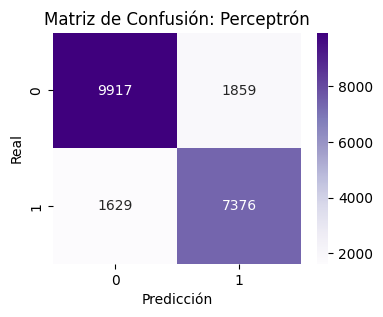

--- Resultados para Regresión Logística ---
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     11776
           1       0.87      0.84      0.86      9005

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781



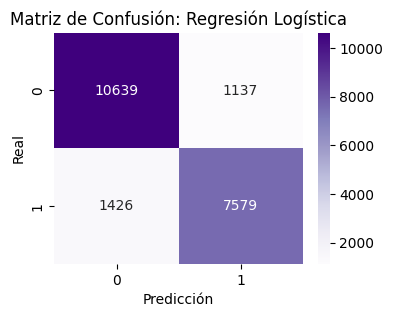

--- Resultados para SVM ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     11776
           1       0.96      0.94      0.95      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



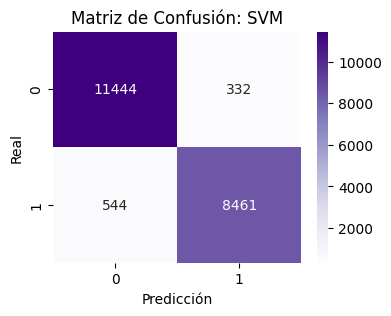

--- Resultados para Árbol de Decisión ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     11776
           1       0.95      0.94      0.95      9005

    accuracy                           0.95     20781
   macro avg       0.95      0.95      0.95     20781
weighted avg       0.95      0.95      0.95     20781



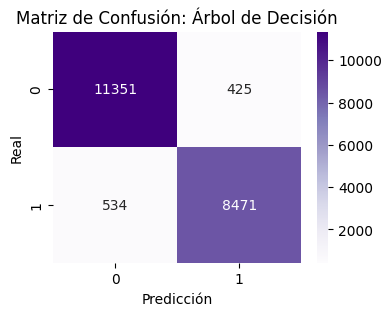

--- Resultados para Random Forest ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.95      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



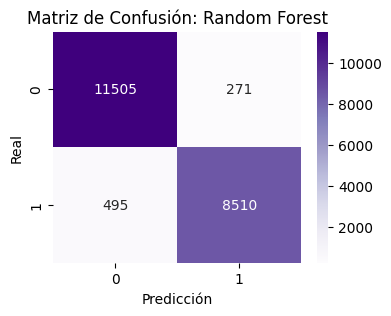

In [24]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Diccionario para centralizar resultados
res_finales = {}

def evaluar_final(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    res_finales[nombre] = {'Accuracy': acc, 'F1-Score': f1}
    
    print(f"--- Resultados para {nombre} ---")
    print(classification_report(y_test, y_pred))
    
    # Visualización de la Matriz de Confusión
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# Evaluación de los modelos entrenados
evaluar_final("Perceptrón", percep_opt, X_test_scaled, y_test)
evaluar_final("Regresión Logística", log_opt, X_test_scaled, y_test)
evaluar_final("SVM", svm_opt, X_test_scaled, y_test)
evaluar_final("Árbol de Decisión", tree_opt, X_test_scaled, y_test)
evaluar_final("Random Forest", rf_opt, X_test_scaled, y_test)

# **5. Análisis de resultados**

En esta sección se analizan y comparan detalladamente los resultados de los cinco modelos entrenados, interpretando su comportamiento en función de la naturaleza del dataset de satisfacción de pasajeros.

TABLA COMPARATIVA DE RENDIMIENTO FINAL


,Accuracy,F1-Score
Random Forest,0.9631,0.9569
SVM,0.9578,0.9508
Árbol de Decisión,0.9539,0.9464
Regresión Logística,0.8767,0.8554
Perceptrón,0.8322,0.8088


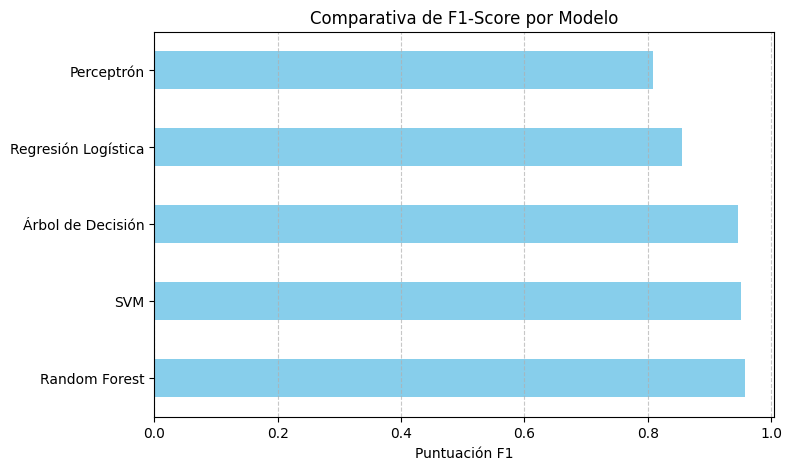

In [25]:
import pandas as pd

# Convertimos el diccionario de resultados en un DataFrame
df_comparativa = pd.DataFrame(res_finales).T

# Ordenamos por F1-Score
df_comparativa = df_comparativa.sort_values(by='F1-Score', ascending=False)

# Formateamos para que sea más legible (redondeo a 4 decimales)
df_comparativa = df_comparativa.round(4)

print("TABLA COMPARATIVA DE RENDIMIENTO FINAL")
display(df_comparativa)

# Visualización de barras para el informe
df_comparativa['F1-Score'].plot(kind='barh', color='skyblue', figsize=(8, 5))
plt.title('Comparativa de F1-Score por Modelo')
plt.xlabel('Puntuación F1')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 5.2. Análisis detallado del comportamiento de los modelos

**Random Forest**

Este modelo opera como un "comité de expertos" compuesto por varios árboles de decisión que votan sobre la clase final. Al utilizar una técnica llamada Bagging, cada árbol analiza una muestra distinta de pasajeros y variables.

Es el modelo más robusto porque detecta que la satisfacción no es lineal. Entiende que un pasajero en Business Class tiene expectativas distintas a uno en Eco. Su éxito radica en capturar interacciones complejas; por ejemplo, que un mal servicio de comida puede ser compensado por un embarque online excelente, algo que solo un sistema de múltiples jerarquías puede procesar con tal precisión.

**SVM**

Tras el escalado de datos, el SVM proyecta a los pasajeros en un espacio multidimensional y busca el margen más ancho posible para separar las labels "Satisfecho" e "Insatisfecho". El uso del kernel RBF le permite crear fronteras curvas y flexibles que permiten separar datos con una naturaleza no lineal.

Su alto rendimiento demuestra que existen perfiles de pasajeros muy bien definidos geográficamente en los datos. Una vez que normalizamos las escalas de variables tan dispares como la "Edad" y la "Distancia de vuelo", el SVM identifica "burbujas" de clientes con opiniones similares, permitiendo una clasificación más precisa.

**Árbol de decisión**

Crea una estructura de flujo lógico (Si/No) basada en las variables que más información aportan para separar las clases.

Su eficacia revela que la satisfacción del cliente a menudo se reduce a unos pocos puntos críticos de control. Variables como Inflight wifi service o Online boarding actúan como "interruptores": si estos fallan, el árbol asigna casi automáticamente la etiqueta de "Insatisfecho", imitando la lógica de frustración directa del pasajero.

**Regresión logística**

Intenta calcular la probabilidad de satisfacción sumando el peso de cada variable de forma lineal.

Su rendimiento moderado sugiere que la satisfacción no es una simple suma de factores. Al intentar trazar una línea recta para separar a los clientes, este modelo no entiende que un excelente servicio de limpieza pueda "compensar" un mal entretenimiento de a bordo, lo que genera un mayor número de errores cuando las opiniones de los pasajeros son matizadas.

**Perceptrón**

Es el algoritmo más simple; actualiza sus pesos basándose únicamente en si se equivoca o no en cada predicción individual.

Al ser el modelo más básico, presenta la mayor inestabilidad. En el contexto de la aerolínea, es demasiado sensible al "ruido" (pasajeros con opiniones atípicas), lo que provoca que clasifique erróneamente a muchos pasajeros satisfechos como insatisfechos (Falsos Negativos), restando fiabilidad al análisis estratégico.

## 5.3. Fuentes de sesgo y errores en las predicciones

Al examinar las matrices de confusión, podemos localizar exactamente dónde fallan los modelos por culpa del sesgo y la varianza

**Sesgo**

Se manifiesta en la alta proporción de falsos negativos. El modelo de Regresión Logística y Perceptrón "sesga" su predicción hacia la insatisfacción porque no es capaz de entender que un buen servicio en una categoría puede compensar un fallo en otra. Es un error por falta de complejidad.

**Varianza**

Se manifiesta en la alta propoción de falsos positivos, presente en el modelo del Árbol de Decisión. Al ser un modelo rígido, si un pasajero cae en una rama de "Satisfecho" por una diferencia mínima en una variable (ej. Wifi de 3 frente a 2), el árbol lo etiqueta sin dudar, aunque el resto de sus respuestas digan lo contrario. El Random Forest corrige esto repartiendo la decisión entre 100 árboles.

**Ruido**

Se detecta en el ~5% de error del Random Forest por falsos positivos y negativos.

Representan a pasajeros cuyas respuestas son contradictorias (ej. todo perfecto pero insatisfechos). No es un fallo del algoritmo, sino un límite de los datos: el modelo no puede predecir el "humor" o incidentes externos no registrados en las características del dataset.

## 5.4. Conclusión

Los datos demuestran que el Random Forest es la herramienta de negocio más segura para la aerolínea, ya que es el que mejor equilibra estas fuentes de error, minimizando especialmente los Falsos Positivos (468), que son los que más dañan la reputación de la empresa si no se detectan a tiempo.